In [121]:
from MLPKAN import MLPKAN
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import random
from kan import KAN, create_dataset
import matplotlib.pyplot as plt

In [122]:
seed = 500
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

MLPKANmodel = MLPKAN(input_size=2, hidden_sizes=[3], output_size=1, subnetworkshape=[12,12,12])


In [123]:
# f = lambda x: x[:, 0]**2 + x[:, 1]**2
f = lambda x: torch.sin(x[:, 0]**2 + 3*x[:, 1])
dataset = create_dataset(f, n_var=2, normalize_input=True, seed=seed)

In [124]:
train_dataset = TensorDataset(dataset['train_input'],dataset['train_label'])
test_dataset = TensorDataset(dataset['test_input'], dataset['test_label'])

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

device = "cpu"

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(MLPKANmodel.parameters(), lr=0.01)

n_epochs = 100
rmse_history = []
for t in range(n_epochs):
    MLPKANmodel.train()
    for batch, (X, y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        pred = MLPKANmodel(X)
        loss = loss_fn(pred, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    MLPKANmodel.eval()
    with torch.no_grad():
        test_pred = MLPKANmodel(dataset['test_input'].to(device))
        rmse_value = torch.sqrt(loss_fn(test_pred, dataset['test_label'].to(device))).item()
        rmse_history.append(rmse_value)
        print(f"Epoch {t+1}/{n_epochs}, RMSE: {rmse_value:.4f}")

Epoch 1/100, RMSE: 0.2920
Epoch 2/100, RMSE: 0.2609
Epoch 3/100, RMSE: 0.1651
Epoch 4/100, RMSE: 0.1339
Epoch 5/100, RMSE: 0.1182
Epoch 6/100, RMSE: 0.1271
Epoch 7/100, RMSE: 0.0786
Epoch 8/100, RMSE: 0.0791
Epoch 9/100, RMSE: 0.0573
Epoch 10/100, RMSE: 0.0506
Epoch 11/100, RMSE: 0.0565
Epoch 12/100, RMSE: 0.1028
Epoch 13/100, RMSE: 0.0414
Epoch 14/100, RMSE: 0.0562
Epoch 15/100, RMSE: 0.0333
Epoch 16/100, RMSE: 0.0522
Epoch 17/100, RMSE: 0.0908
Epoch 18/100, RMSE: 0.1119
Epoch 19/100, RMSE: 0.0494
Epoch 20/100, RMSE: 0.0480
Epoch 21/100, RMSE: 0.0652
Epoch 22/100, RMSE: 0.0342
Epoch 23/100, RMSE: 0.0372
Epoch 24/100, RMSE: 0.0283
Epoch 25/100, RMSE: 0.0348
Epoch 26/100, RMSE: 0.0243
Epoch 27/100, RMSE: 0.0330
Epoch 28/100, RMSE: 0.0227
Epoch 29/100, RMSE: 0.0333
Epoch 30/100, RMSE: 0.0318
Epoch 31/100, RMSE: 0.0330
Epoch 32/100, RMSE: 0.0228
Epoch 33/100, RMSE: 0.0310
Epoch 34/100, RMSE: 0.0596
Epoch 35/100, RMSE: 0.0903
Epoch 36/100, RMSE: 0.0456
Epoch 37/100, RMSE: 0.0288
Epoch 38/1

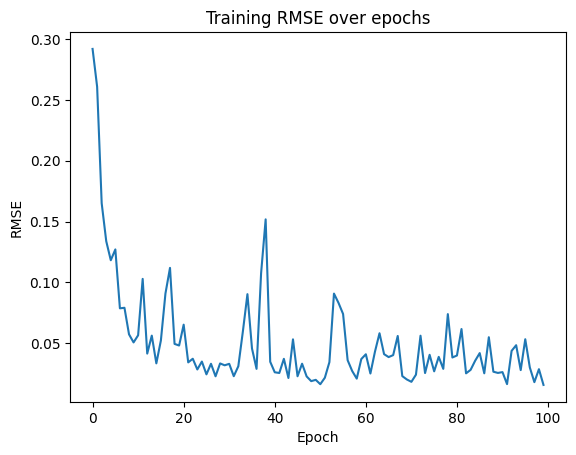

In [125]:
plt.plot(rmse_history)
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title('Training RMSE over epochs')
plt.show()



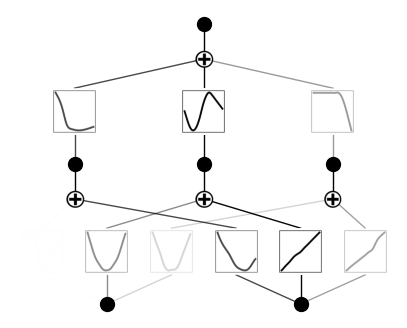

In [126]:
kanmodel = KAN(width=[2,3,1], seed=seed, grid=10, auto_save=False, symbolic_enabled=False)
kanmodel.set_splines_MLPKAN(dataset['test_input'], MLPKANmodel)
kanmodel.plot()